## LLM Node + LLM-Driven Conditional Routing


In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv


load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

In [18]:
from typing import TypedDict, Annotated, Literal
import operator
from langchain_core.messages import BaseMessage


# --- 1. STATE ---
class State(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]
    category: str  # "question", "task", or "chitchat"
    response: str

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage


# --- 2. NODES ---
def classify_node(state: State) -> dict:
    """Ask the LLM to classify the user's message"""
    user_msg = state["messages"][-1].content
    resp = llm.invoke(
        [
            SystemMessage("Classify the user message into exactly one word: 'question', 'task', or 'chitchat'."),
            HumanMessage(user_msg),
        ]
    )
    category = resp.content.strip().lower()
    print(f"[classify] → '{category}'")
    return {"category": category}


def answer_node(state: State) -> dict:
    """Handle factual questions"""
    resp = llm.invoke([SystemMessage("You are a knowledgeable assistant.")] + state["messages"])
    return {"response": resp.content}


def task_node(state: State) -> dict:
    """Handle action/task requests"""
    resp = llm.invoke(
        [SystemMessage("You are a task-oriented assistant. Be direct and structured.")] + state["messages"]
    )
    return {"response": resp.content}


def chitchat_node(state: State) -> dict:
    """Handle casual conversation"""
    resp = llm.invoke([SystemMessage("You are a friendly, casual, fun assistant. Keep it short!")] + state["messages"])
    return {"response": resp.content}


# --- 3. ROUTING ---
def route_by_category(state: State) -> Literal["answer", "task", "chitchat"]:
    cat = state["category"]
    if "question" in cat:
        return "answer"
    if "task" in cat:
        return "task"
    return "chitchat"

In [20]:
from langgraph.graph import StateGraph, START, END

# --- 4. GRAPH ---
builder = StateGraph(State)
builder.add_node("classify", classify_node)
builder.add_node("answer", answer_node)
builder.add_node("task", task_node)
builder.add_node("chitchat", chitchat_node)

builder.add_edge(START, "classify")
builder.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "answer": "answer",
        "task": "task",
        "chitchat": "chitchat",
    },
)
for node in ["answer", "task", "chitchat"]:
    builder.add_edge(node, END)

graph = builder.compile()

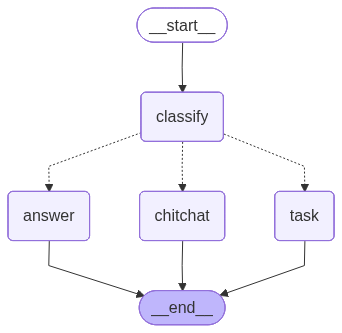

In [21]:
# --- 5. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
# --- 6. RUN & TEST ---
user_text: str = "What is the capital of India?"
r = graph.invoke(
    {
        "messages": [HumanMessage(user_text)],
        "category": "",
        "response": "",
    }
)
print(f"\n❓ '{user_text}'")
print(f"📂 Category: {r['category']}")
print(f"💬 Response: {r['response']}...")
print("-" * 30)

[classify] → 'question'

❓ 'What is the capital of India?'
📂 Category: question
💬 Response: The capital of India is New Delhi....
------------------------------


In [23]:
# --- 6. RUN & TEST ---
user_text: str = "Write me a Python function to reverse a string"
r = graph.invoke(
    {
        "messages": [HumanMessage(user_text)],
        "category": "",
        "response": "",
    }
)
print(f"\n❓ '{user_text}'")
print(f"📂 Category: {r['category']}")
print(f"💬 Response: {r['response']}...")
print("-" * 30)

[classify] → 'task'

❓ 'Write me a Python function to reverse a string'
📂 Category: task
💬 Response: Here is a simple Python function that reverses a string:

```python
def reverse_string(s):
    return s[::-1]

# Example usage
input_string = "Hello, World!"
reversed_string = reverse_string(input_string)
print(reversed_string)  # Output: !dlroW ,olleH
```

### Explanation:
- The function `reverse_string` takes a string `s` as an argument.
- The slice `s[::-1]` is used to reverse the string.
- The reversed string is then returned. 

You can test it with any string by changing the `input_string`....
------------------------------


In [24]:
# --- 6. RUN & TEST ---
user_text: str = "Hey! How's your day going?"
r = graph.invoke(
    {
        "messages": [HumanMessage(user_text)],
        "category": "",
        "response": "",
    }
)
print(f"\n❓ '{user_text}'")
print(f"📂 Category: {r['category']}")
print(f"💬 Response: {r['response']}...")
print("-" * 30)

[classify] → 'chitchat'

❓ 'Hey! How's your day going?'
📂 Category: chitchat
💬 Response: Hey! I’m having a great day, thanks for asking! How about you? 😊...
------------------------------
